 Week 4 Hands-On: Data Exploration, Feature Engineering, and Modeling
Dataset: Wisconsin Breast Cancer Dataset (built into scikit-learn)
Task: Binary classification — predict whether a tumor is malignant or benign
Libraries: NumPy, pandas, Matplotlib, scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All libraries loaded successfully.")

All libraries loaded successfully.


Data Loading & Exploration
The Breast Cancer Wisconsin dataset contains 569 samples with 30 numeric features computed from tumor biopsy images. The target is binary: 0 = malignant, 1 = benign.

In [3]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
df["target_name"] = df["target"].map({0: "malignant", 1: "benign"})
print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['target_name'].value_counts()}")
df.head()

Shape: (569, 32)

Class distribution:
target_name
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [4]:
df[["mean radius", "mean texture", "mean area", "mean concavity", "target"]].describe().round(3)

,mean radius,mean texture,mean area,mean concavity,target
count,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,654.889,0.089,0.627
std,3.524,4.301,351.914,0.080,0.484
min,6.981,9.710,143.500,0.000,0.000
25%,11.700,16.170,420.300,0.030,0.000
50%,13.370,18.840,551.100,0.062,1.000
75%,15.780,21.800,782.700,0.131,1.000
max,28.110,39.280,2501.000,0.427,1.000


In [5]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values.")

No missing values.


Visualizations
Class Distribution & Mean Radius
The bar chart shows the dataset is moderately imbalanced — more benign cases than malignant. The histogram shows malignant tumors tend to have larger mean radius values, suggesting it's a useful feature.

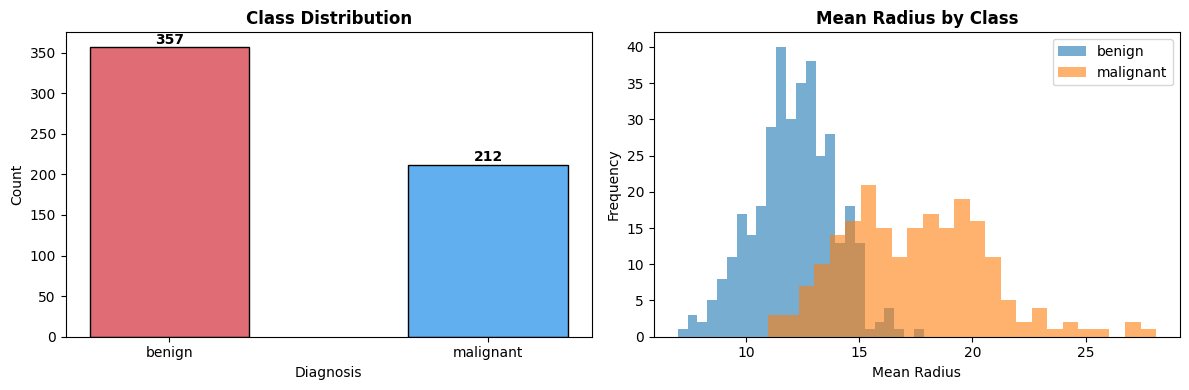

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df["target_name"].value_counts()
axes[0].bar(counts.index, counts.values, color=["#e06c75", "#61afef"], edgecolor="black", width=0.5)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 4, str(v), ha="center", fontweight="bold")
for label, group in df.groupby("target_name"):
    axes[1].hist(group["mean radius"], bins=25, alpha=0.6, label=label)
axes[1].set_title("Mean Radius by Class", fontweight="bold")
axes[1].set_xlabel("Mean Radius")
axes[1].set_ylabel("Frequency")
axes[1].legend()
plt.tight_layout()
plt.show()

Scatter Plot: Mean Radius vs. Mean Concavity
Malignant tumors cluster toward higher radius and higher concavity. The classes aren't perfectly separable, which motivates using a non-linear model like Random Forest.

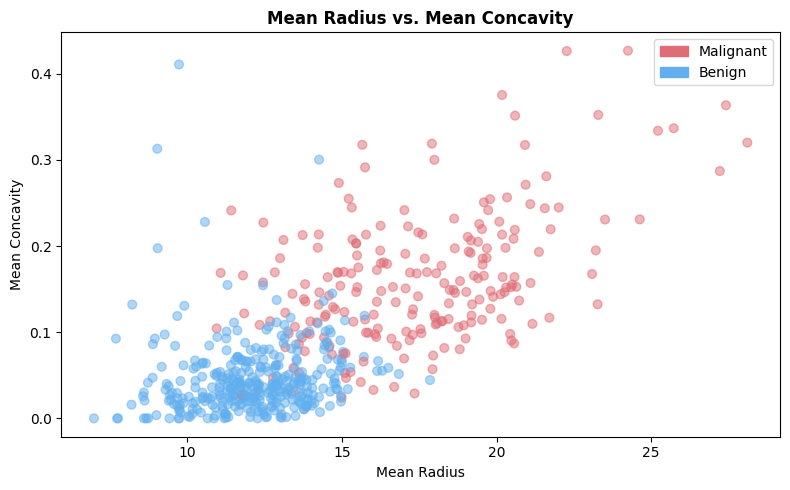

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = df["target"].map({0: "#e06c75", 1: "#61afef"})
ax.scatter(df["mean radius"], df["mean concavity"], c=colors, alpha=0.5, s=40)
handles = [mpatches.Patch(color="#e06c75", label="Malignant"),
           mpatches.Patch(color="#61afef", label="Benign")]
ax.legend(handles=handles)
ax.set_title("Mean Radius vs. Mean Concavity", fontweight="bold")
ax.set_xlabel("Mean Radius")
ax.set_ylabel("Mean Concavity")
plt.tight_layout()
plt.show()

Feature Engineering
Binning + One-Hot Encoding
mean area is binned into small, medium, and large categories using pd.cut(), then one-hot encoded. This can expose threshold effects a raw numeric value might miss.
Interaction Feature
A new feature radius_texture_ratio is created by dividing mean radius by mean texture. Malignant cells often have irregular texture relative to their size, so this ratio may carry extra signal.

In [8]:
df["area_bin"] = pd.cut(df["mean area"], bins=3, labels=["small", "medium", "large"])
print(df["area_bin"].value_counts().sort_index())
df_engineered = pd.get_dummies(df.drop(columns=["target_name"]), columns=["area_bin"])
df_engineered["radius_texture_ratio"] = df_engineered["mean radius"] / df_engineered["mean texture"]
print(f"\nShape after engineering: {df_engineered.shape}")
df_engineered[["mean area", "area_bin_small", "area_bin_medium", "area_bin_large", "radius_texture_ratio"]].head()

area_bin
small     460
medium    101
large       8
Name: count, dtype: int64

Shape after engineering: (569, 35)


,mean area,area_bin_small,area_bin_medium,area_bin_large,radius_texture_ratio
0,1001.0,False,True,False,1.733141
1,1326.0,False,True,False,1.157569
2,1203.0,False,True,False,0.926588
3,386.1,True,False,False,0.560353
4,1297.0,False,True,False,1.414923


Model Training & Evaluation
Two models are trained and compared using an 80/20 train/test split:

Logistic Regression — linear baseline
Random Forest — non-linear ensemble

Both use a Pipeline with StandardScaler so scaling is applied consistently.

In [9]:
X = df_engineered.drop(columns=["target"])
y = df_engineered["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

lr_pipe = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
rf_pipe = Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))])

lr_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

lr_pred = lr_pipe.predict(X_test)
rf_pred = rf_pipe.predict(X_test)

print("LOGISTIC REGRESSION")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred, target_names=data.target_names))
print("RANDOM FOREST")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred, target_names=data.target_names))

LOGISTIC REGRESSION
Accuracy: 0.9825
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

RANDOM FOREST
Accuracy: 0.9561
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



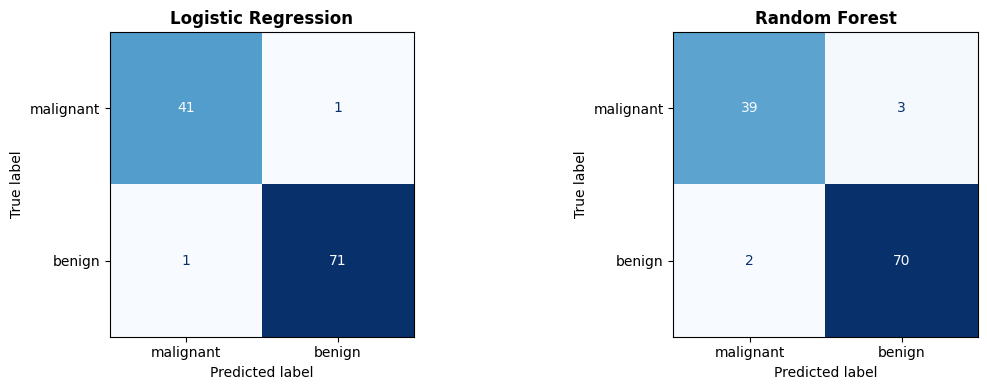

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, title in zip(axes, [lr_pred, rf_pred], ["Logistic Regression", "Random Forest"]):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=data.target_names, ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontweight="bold")
plt.tight_layout()
plt.show()

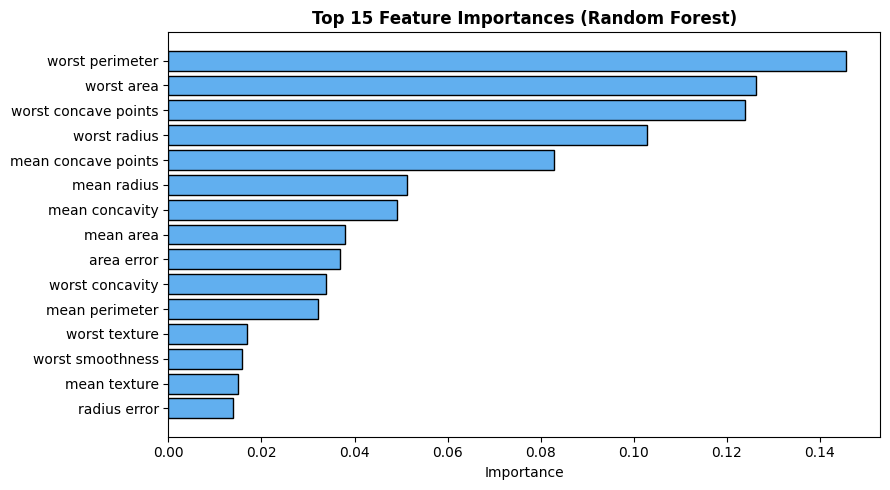

In [11]:
importances = rf_pipe.named_steps["clf"].feature_importances_
top_idx = np.argsort(importances)[-15:]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(X.columns[top_idx], importances[top_idx], color="#61afef", edgecolor="black")
ax.set_title("Top 15 Feature Importances (Random Forest)", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

Reflection
What was challenging about feature engineering?
The binning strategy for mean area was trickier than expected. Equal-width bins created imbalanced groups because the distribution is right-skewed most samples fall in the small/medium range. Quantile binning would be a better choice next time.
How did feature choices affect performance?
The radius_texture_ratio feature appeared in the top 15 Random Forest importances, confirming it adds real signal. The area bins contributed less, suggesting the raw mean area value already captures most of that information.

How could you improve next time?
1.Use ColumnTransformer inside the pipeline to prevent data leakage
2.Apply QuantileTransformer to normalize skewed features
3.Tune hyperparameters with GridSearchCV
Use cross-validation instead of a single train/test split
4.Add SHAP values for deeper model interpretability